
# Causal Inference — Lab 2: Probability Review

- **Part I — one random variable:** PMF, PDF, CDF, expectation, variance.  *(Review 1)*
- **Part II — several random variables:** joint & marginal distributions, covariance,
  correlation, conditional expectation, the Law of Iterated Expectations, independence.  *(Review 2)*

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats          # only used to double-check our by-hand answers

sns.set_theme(context="notebook", style="whitegrid")
np.random.seed(201)



# Part I — One random variable  *(Probability Review 1)*

A **random variable (RV)** is a number whose value is uncertain until we observe it.
Its **distribution** says how likely each value is.

- **Discrete** RV: finitely many values (die roll, coin flip, "went to college?").
- **Continuous** RV: a continuum of values (height, income, where a spinner lands).



## I.1 Probability Mass Function (PMF) — discrete RVs

The PMF gives the probability of each individual value: $P(X=x)$. Two rules:

- every value is in $[0,1]$, and
- they **sum to 1** (exactly one outcome happens).

A fair die has $P(X=x)=\tfrac16$ for $x\in\{1,\dots,6\}$. A coin is **Bernoulli**:
$P(X=1)=p,\ P(X=0)=1-p$.


In [3]:
def pmf_die(x):
    # PMF of a fair six-sided die
    return 1/6 if x in (1, 2, 3, 4, 5, 6) else 0

def pmf_bernoulli(x, p=0.5):
    # PMF of a coin flip: 1 = heads, 0 = tails
    if x == 1: return p
    if x == 0: return 1 - p
    return 0

print("Die PMF sums to:", sum(pmf_die(x) for x in range(1, 7)))
print("Coin PMF sums to:", pmf_bernoulli(1) + pmf_bernoulli(0))


Die PMF sums to: 0.9999999999999999
Coin PMF sums to: 1.0


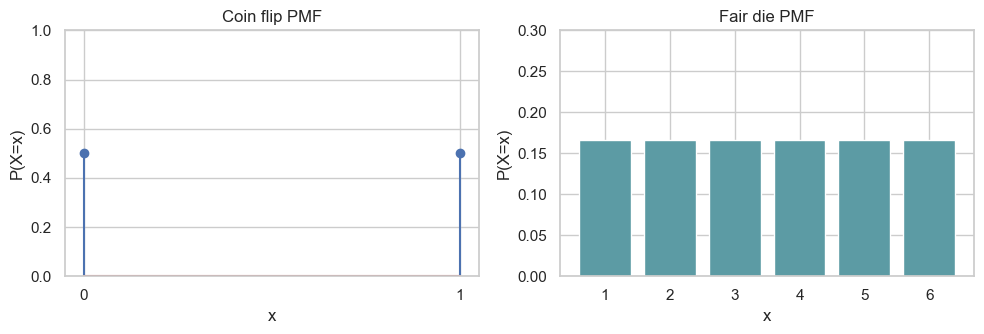

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(10, 3.5))

ax[0].stem([0, 1], [pmf_bernoulli(0), pmf_bernoulli(1)])
ax[0].set(title="Coin flip PMF", xlabel="x", ylabel="P(X=x)", xticks=[0, 1], ylim=(0, 1))

faces = range(1, 7)
ax[1].bar(list(faces), [pmf_die(x) for x in faces], color="#5c9ba4")
ax[1].set(title="Fair die PMF", xlabel="x", ylabel="P(X=x)", ylim=(0, 0.3))
plt.tight_layout(); plt.show()



## I.2 Probability Density Function (PDF) — continuous RVs

For a continuous RV we use a **density** $f(x)$, not point probabilities. In fact
$P(X=x)=0$ for every individual single point, as there are infinitely many points. Instead, **probability is
area under the curve**:

$$P(a < X < b) = \int_a^b f(x)\,dx, \qquad \int_{-\infty}^{\infty} f(x)\,dx = 1.$$

Two examples: the **Uniform**$(a,b)$ with $f(x)=\tfrac{1}{b-a}$, and the **Gaussian** (Normal).


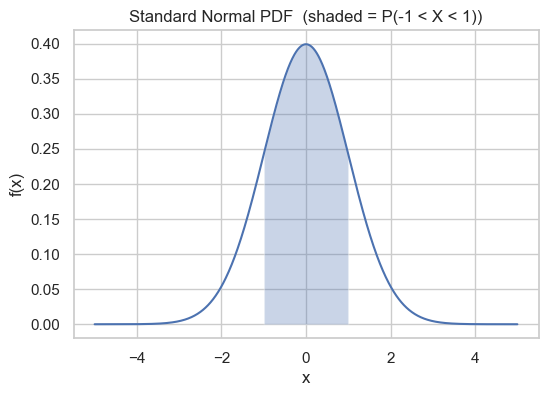

In [5]:
def pdf_uniform(x, a, b):
    return np.where((x >= a) & (x <= b), 1/(b - a), 0.0)

def pdf_gaussian(x, mu, sigma):
    return np.exp(-0.5 * ((x - mu)/sigma)**2) / (sigma * np.sqrt(2*np.pi))

x = np.linspace(-5, 5, 1000)
plt.figure(figsize=(6, 4))
plt.plot(x, pdf_gaussian(x, 0, 1))
plt.fill_between(x, pdf_gaussian(x, 0, 1), where=(x > -1) & (x < 1), alpha=0.3)
plt.title("Standard Normal PDF  (shaded = P(-1 < X < 1))")
plt.xlabel("x"); plt.ylabel("f(x)"); plt.show()



**"Area = probability" in code.** We approximate an integral by a Riemann sum:
$\int f(x)\,dx \approx \sum f(x_i)\,\Delta x$. Let's check the total area is 1 and that
the shaded band above is about 0.68.


In [6]:
dx = x[1] - x[0]                       # width of each slice
total_area = np.sum(pdf_gaussian(x, 0, 1)) * dx
band = (x > -1) & (x < 1)
p_band = np.sum(pdf_gaussian(x[band], 0, 1)) * dx

print(f"Total area under the Normal pdf : {total_area:.4f}   (should be 1)")
print(f"P(-1 < X < 1) by Riemann sum    : {p_band:.4f}")
print(f"P(-1 < X < 1) exact (scipy)     : {stats.norm.cdf(1) - stats.norm.cdf(-1):.4f}")


Total area under the Normal pdf : 1.0000   (should be 1)
P(-1 < X < 1) by Riemann sum    : 0.6832
P(-1 < X < 1) exact (scipy)     : 0.6827



## I.3 Cumulative Distribution Function (CDF)

The CDF accumulates probability up to a point:

$$F(x) = P(X \le x).$$

- From a **PMF**: add up the masses up to $x$.
- From a **PDF**: integrate the density up to $x$.

First a discrete example — the coin flip — which is a step function.


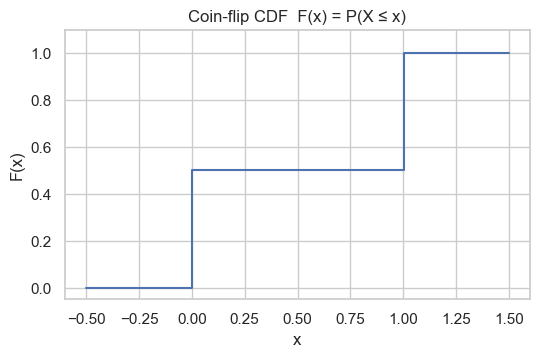

In [7]:
xs = np.linspace(-0.5, 1.5, 500)
cdf_coin = np.where(xs < 0, 0.0, np.where(xs < 1, 0.5, 1.0))
plt.figure(figsize=(6, 3.5))
plt.step(xs, cdf_coin, where="post")
plt.title("Coin-flip CDF  F(x) = P(X ≤ x)")
plt.xlabel("x"); plt.ylabel("F(x)"); plt.ylim(-0.05, 1.1); plt.show()


- **Below 0** (`x < 0`): we haven't reached any possible outcome yet, so
  $F(x) = 0$ — the flat bottom.
- **From 0 up to (not including) 1**: we've now passed tails ($X=0$, prob 0.5) but
  not heads, so $F(x) = 0.5$ — the middle step.
- **At 1 and above**: we've passed both outcomes, so all the probability is
  accounted for and $F(x) = 1$ — the top step.


#### A common trap: a raw `cumulative sum` is not a CDF

To get a CDF from a pdf we integrate, so we must multiply by the slice width $\Delta x$
(or, equivalently, normalize so the last value is 1). Just summing the density values
overshoots. Watch:


In [9]:
pdf_vals = pdf_gaussian(x, 0, 1)

wrong = np.cumsum(pdf_vals)              # forgot the * dx  -> ends around 100, not 1
right = np.cumsum(pdf_vals) * dx         # proper Riemann integral -> ends at ~1

print(f"Raw cumsum final value  : {wrong[-1]:.2f}   <- NOT a probability")
print(f"cumsum * dx final value : {right[-1]:.3f}   <- correct, ≈ 1")

Raw cumsum final value  : 99.90   <- NOT a probability
cumsum * dx final value : 1.000   <- correct, ≈ 1



## I.4 Expectation (the mean)

The **expectation** is the long-run average value of the RV:

$$\mathbb{E}[X]=\sum_i x_i\,p(x_i)\ \text{(discrete)}, \qquad
  \mathbb{E}[X]=\int x\,f(x)\,dx\ \text{(continuous)}.$$

Check two facts from the slides: $\mathbb{E}[\text{coin}]=0.5$ and
$\mathbb{E}[\text{Uniform}(a,b)]=\tfrac{a+b}{2}$. We verify each by formula and by
simulating many draws (the sample mean should land near the true mean).


In [10]:
# Coin
E_coin_formula = 0*pmf_bernoulli(0) + 1*pmf_bernoulli(1)
E_coin_sim = np.random.binomial(1, 0.5, 100_000).mean()
print(f"E[coin]  formula={E_coin_formula:.2f}   simulation={E_coin_sim:.3f}")

# Uniform(a, b)
a, b = 0, 360                                  # the 'spinner' from the slides
E_unif_formula = (a + b) / 2
E_unif_sim = np.random.uniform(a, b, 100_000).mean()
print(f"E[Unif]  formula={E_unif_formula:.2f}  simulation={E_unif_sim:.2f}")


E[coin]  formula=0.50   simulation=0.502
E[Unif]  formula=180.00  simulation=180.05



## I.5 Functions of a random variable

If $X$ is random, so is $g(X)$ — the randomness "passes through" the function. Its
expectation weights each transformed value by the *original* probability:

$$\mathbb{E}[g(X)] = \sum_i g(x_i)\,p(x_i).$$

Example: a die roll $X$ and its square $X^2$.


In [11]:
faces = np.arange(1, 7)
E_X   = sum(x * pmf_die(x) for x in faces)
E_X2  = sum(x**2 * pmf_die(x) for x in faces)     # E[g(X)] with g(x)=x^2

rolls = np.random.randint(1, 7, 200_000)
print(f"E[X]   formula={E_X:.3f}   simulation={rolls.mean():.3f}")
print(f"E[X^2] formula={E_X2:.3f}  simulation={(rolls**2).mean():.3f}")


E[X]   formula=3.500   simulation=3.503
E[X^2] formula=15.167  simulation=15.190



## I.6 Variance & standard deviation

**Variance** measures spread — how far $X$ lands from its own mean on average:

$$\operatorname{Var}(X)=\mathbb{E}[(X-\mathbb{E}[X])^2]
 \;=\; \underbrace{\mathbb{E}[X^2]-\mathbb{E}[X]^2}_{\text{handy alternative form}}.$$

The **standard deviation** $\sigma=\sqrt{\operatorname{Var}(X)}$ is in the same units as $X$.

A useful property for linear transformations of variance: $\operatorname{Var}(a+bX)=b^2\operatorname{Var}(X)$ (shifting doesn't change
spread; scaling by $b$ scales variance by $b^2$).


In [12]:
# Verify the two variance formulas agree, on the die
var_def = sum((x - E_X)**2 * pmf_die(x) for x in faces)   # E[(X-E X)^2]
var_alt = E_X2 - E_X**2                                    # E[X^2] - E[X]^2
print(f"Var(die) definition = {var_def:.4f}")
print(f"Var(die) alt form   = {var_alt:.4f}   (identical ✓)")

# Verify Var(a + bX) = b^2 Var(X) by simulation
X = np.random.randn(200_000)
a, b = 5, 3
print(f"\nVar(X)          = {X.var():.3f}")
print(f"Var(a + bX)     = {(a + b*X).var():.3f}")
print(f"b^2 * Var(X)    = {b**2 * X.var():.3f}   (matches ✓)")


Var(die) definition = 2.9167
Var(die) alt form   = 2.9167   (identical ✓)

Var(X)          = 1.005
Var(a + bX)     = 9.048
b^2 * Var(X)    = 9.048   (matches ✓)



# Part II — Several random variables  *(Probability Review 2)*



## II.1 Joint distributions

A **joint distribution** describes two (or more) variables at once: $P(X=x, Y=y)$
(discrete) or $f(x,y)$ (continuous). Think of any person having *both* a height and a sex —
jointly distributed.

We'll use a height/sex dataset. *In the course you load the provided `2-data.csv`; here we
simulate an equivalent dataset so the notebook runs on its own.*


In [19]:
# Load the real dataset: Height (cm), Weight (kg), Sex for 3000 people
df = pd.read_csv("Causal Inference Data 2.csv")
print("Raw data:", df.shape)

# A handful of rows have impossible values (a 3050 cm height, an 8.5 kg adult, ...)
#We drop them so they don't distort our
# probabilities.
df = df[df["Height"].between(120, 230) & df["Weight"].between(30, 250)].reset_index(drop=True)
print("After removing impossible values:", df.shape)   # 2981 rows kept

df.head()

Raw data: (3000, 3)
After removing impossible values: (2981, 3)


,Height,Weight,Sex
0,165.65,35.41,Female
1,148.53,74.45,Female
2,167.04,81.22,Male
3,161.54,71.47,Male
4,174.31,78.18,Male



An **empirical** joint probability is just a count divided by the total: this is just the observed joint probability

$$P(H>h,\ G=\text{Male}) = \frac{N_{h,\text{Male}}}{N}.$$


In [20]:
h = 180
joint_male = len(df[(df["Height"] > h) & (df["Sex"] == "Male")]) / len(df)
print(f"P(Height > {h} and Male) = {joint_male:.3f}")


P(Height > 180 and Male) = 0.084



## II.2 From joint to marginal

The **marginal** distribution of one variable is recovered by summing the joint over the
other variable:

$$P(H>h) = \sum_g P(H>h,\ G=g).$$

Here, $P(H>h)$ = (tall AND male) + (tall AND female)


In [ ]:
p_h_male   = len(df[(df["Height"] > h) & (df["Sex"] == "Male")])   / len(df)
p_h_female = len(df[(df["Height"] > h) & (df["Sex"] == "Female")]) / len(df)
p_h_direct = len(df[df["Height"] > h]) / len(df)

print(f"P(H>{h}, Male)   = {p_h_male:.3f}")
print(f"P(H>{h}, Female) = {p_h_female:.3f}")
print(f"Sum (marginal)   = {p_h_male + p_h_female:.3f}")
print(f"Direct P(H>{h})  = {p_h_direct:.3f}   (matches the sum ✓)")what 


P(H>180, Male)   = 0.084
P(H>180, Female) = 0.001
Sum (marginal)   = 0.086
Direct P(H>180)  = 0.086   (matches the sum ✓)



## II.3 Covariance

**Covariance** asks: when $X$ is above its mean, does $Y$ tend to be above its mean too?

$$\operatorname{Cov}(X,Y)=\mathbb{E}[(X-\mathbb{E}X)(Y-\mathbb{E}Y)]=\mathbb{E}[XY]-\mathbb{E}[X]\mathbb{E}[Y].$$

Sign is what matters: **+** move together, **−** move oppositely, **0** no *linear* co-movement.

Properties: $\operatorname{Cov}(X,Y)=\operatorname{Cov}(Y,X)$

$\operatorname{Cov}(X,a)=0$ when a is a constant


$\operatorname{Cov}(a+bX,Y)=b\operatorname{Cov}(X,Y)$.

`np.cov` returns the 2×2 **covariance matrix**: diagonal = variances, off-diagonal = covariance.


In [ ]:
X = np.random.randn(1000) #1000 numbers from standard Normal
Y_pos   = 2*X + 1                 # perfectly, positively linearly related with X
Y_const = np.zeros(1000)         # constant -> covaries with nothing, just 0s

print("Cov matrix for (X, 2X+1):")
print(np.cov(X, Y_pos))
print("\nCov(X, 2X+1) =", np.cov(X, Y_pos)[0, 1], " (large & positive)")
print("Cov(X, const) =", np.cov(X, Y_const)[0, 1], " (≈ 0)")


Cov matrix for (X, 2X+1):
[[0.97788605 1.95577211]
 [1.95577211 3.91154422]]

Cov(X, 2X+1) = 1.9557721093448335  (large & positive)
Cov(X, const) = 0.0  (≈ 0)



## II.4 Variance of a sum
Covariance shows up when you add random variables:

$$\operatorname{Var}(X+Y)=\operatorname{Var}(X)+\operatorname{Var}(Y)+2\operatorname{Cov}(X,Y).$$

(For a difference the last term flips sign; for $aX+bY$ it becomes $2ab\operatorname{Cov}(X,Y)$.)


In [26]:
X = np.random.randn(100_000)
Y = 2*X + np.random.randn(100_000)      # correlated with X
cov_xy = np.cov(X, Y)[0, 1]

lhs = np.var(X + Y)
rhs = np.var(X) + np.var(Y) + 2*cov_xy
print(f"Var(X+Y)                     = {lhs:.3f}")
print(f"Var(X)+Var(Y)+2Cov(X,Y)      = {rhs:.3f}   (matches ✓)")


Var(X+Y)                     = 9.995
Var(X)+Var(Y)+2Cov(X,Y)      = 9.995   (matches ✓)



## II.5 Correlation

Covariance has units of $X$ × units of $Y$. Correlation rescales it to
be unitless and bounded:

$$\rho_{X,Y}=\frac{\operatorname{Cov}(X,Y)}{\sqrt{\operatorname{Var}(X)\operatorname{Var}(Y)}}\in[-1,1].$$

(The bound is the Cauchy–Schwarz inequality.) Interpretation:

- $\rho = +1$: perfect increasing line (perfect linear corr), $Y=a+bX$ with $b>0$.
- $\rho = -1$: perfect decreasing line (perfect linear negative corr), $b<0$.
- $\rho = 0$: **no *linear* relationship**.

> ⚠️ **$\rho=0$ does *not* mean independent.** Zero correlation only rules out a *linear*
> relationship; the variables can still be strongly related in a curved way. We prove this
> to ourselves in §II.11.


In [27]:
def corr(a, bvec): return np.corrcoef(a, bvec)[0, 1]

X = np.random.randn(5000)
print(f"corr(X, 2X+1)            = {corr(X, 2*X + 1):+.3f}   (→ +1)")
print(f"corr(X, -3X+4)           = {corr(X, -3*X + 4):+.3f}   (→ -1)")
print(f"corr(X, 2X + big noise)  = {corr(X, 2*X + 5*np.random.randn(5000)):+.3f}   (weaker)")


corr(X, 2X+1)            = +1.000   (→ +1)
corr(X, -3X+4)           = -1.000   (→ -1)
corr(X, 2X + big noise)  = +0.364   (weaker)



## II.6 Correlation $\not\Rightarrow$ Causation

Two variables can be correlated because a **common cause** drives both. Classic example:
ice-cream sales and drownings both rise in hot weather — neither causes the other.

We can draw the causal story as a **DAG** (directed acyclic graph): hot weather $W$ points
to both ice cream $I$ and drownings $D$.


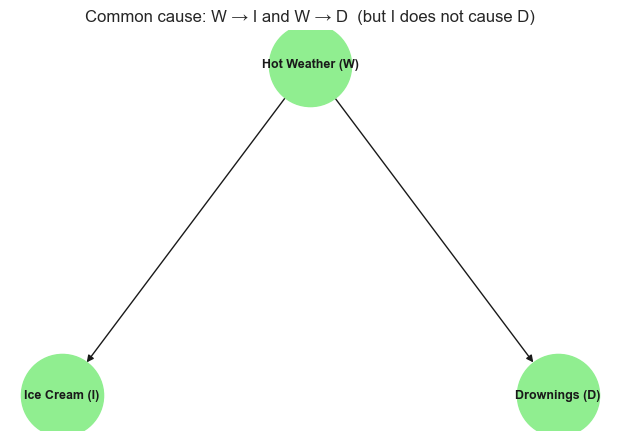

In [29]:
import networkx as nx

G = nx.DiGraph([("Hot Weather (W)", "Ice Cream (I)"),
                ("Hot Weather (W)", "Drownings (D)")])
pos = {"Hot Weather (W)": (0, 1), "Ice Cream (I)": (-1, 0), "Drownings (D)": (1, 0)}
plt.figure(figsize=(6, 4))
nx.draw(G, pos, with_labels=True, node_size=3500, node_color="lightgreen",
        font_size=9, font_weight="bold", arrows=True)
plt.title("Common cause: W → I and W → D  (but I does not cause D)")
plt.show()


In [ ]:
np.random.seed(42)
n = 5000
hot = np.random.binomial(1, 0.3, n)                                   # weather
ice = np.where(hot == 1, np.random.binomial(1, 0.8, n),
                          np.random.binomial(1, 0.1, n))              # W -> I
drown = np.where(hot == 1, np.random.binomial(1, 0.2, n),
                            np.random.binomial(1, 0.05, n))           # W -> D
d = pd.DataFrame({"Hot": hot, "Ice": ice, "Drown": drown})

print(f"corr(Ice, Drown)          = {d['Ice'].corr(d['Drown']):+.3f}  <- looks causal!")
print(f"corr(Ice, Hot)            = {d['Ice'].corr(d['Hot']):+.3f}")
print(f"corr(Drown, Hot)          = {d['Drown'].corr(d['Hot']):+.3f}")

print("\nDrowning rate by ice-cream sales, WITHIN each weather group:")
print(d.groupby(["Hot", "Ice"])["Drown"].mean())


corr(Ice, Drown)          = +0.154  <- looks causal!
corr(Ice, Hot)            = +0.686
corr(Drown, Hot)          = +0.243

Drowning rate by ice-cream sales, WITHIN each weather group:
Hot  Ice
0    0      0.059550
     1      0.040214
1    0      0.231034
     1      0.219492
Name: Drown, dtype: float64



**What to notice:** Ice cream and drownings look correlated, but once we hold weather fixed
(look *within* Hot=0 and Hot=1) the association essentially disappears — the link was the
common cause, not causation.



## II.7 Causation $\not\Rightarrow$ Correlation

The reverse also fails. Antihistamines *reduce* sneezing, yet people who take them sneeze
*more* than average, because a hidden condition $C$ (allergies) causes both taking the
drug and sneezing. The true (negative) effect can be masked, or even flipped, in the raw
correlation.


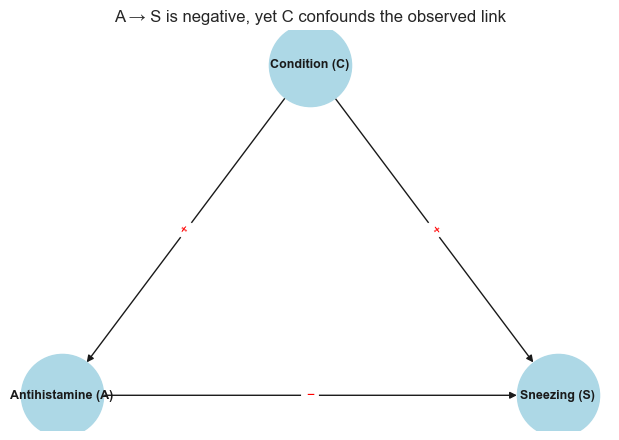

In [31]:
G = nx.DiGraph([("Condition (C)", "Antihistamine (A)"),
                ("Condition (C)", "Sneezing (S)"),
                ("Antihistamine (A)", "Sneezing (S)")])
pos = {"Condition (C)": (0, 1), "Antihistamine (A)": (-1, 0), "Sneezing (S)": (1, 0)}
labels = {("Condition (C)", "Antihistamine (A)"): "+",
          ("Condition (C)", "Sneezing (S)"): "+",
          ("Antihistamine (A)", "Sneezing (S)"): "−"}
plt.figure(figsize=(6, 4))
nx.draw(G, pos, with_labels=True, node_size=3500, node_color="lightblue",
        font_size=9, font_weight="bold", arrows=True)
nx.draw_networkx_edge_labels(G, pos, edge_labels=labels, font_color="red")
plt.title("A → S is negative, yet C confounds the observed link")
plt.show()


In [32]:
np.random.seed(42)
n = 5000
p_condition = 0.2
alpha_c1, alpha_c0 = 0.8, 0.1     # baseline sneeze rate with / without allergies
beta  = 0.5                       # TRUE effect of the drug: reduces sneezing
gamma = 0.9                       # allergic people usually take the drug

C = np.random.binomial(1, p_condition, n)
A = np.random.binomial(1, gamma * C)                       # C -> A
sneeze_p = np.where(C == 1, alpha_c1 - beta * A, alpha_c0) # A lowers it (given C)
S = np.random.binomial(1, sneeze_p)
d = pd.DataFrame({"C": C, "A": A, "S": S})

print(f"Observed corr(Antihistamine, Sneezing) = {d['A'].corr(d['S']):+.3f}  <- positive!")
print("\nSneeze rate by drug use:")
print(d.groupby('A')['S'].mean())
print("\nBut WITHIN allergy sufferers (C=1), the drug lowers sneezing:")
print(d[d.C == 1].groupby('A')['S'].mean())


Observed corr(Antihistamine, Sneezing) = +0.182  <- positive!

Sneeze rate by drug use:
A
0    0.121707
1    0.292222
Name: S, dtype: float64

But WITHIN allergy sufferers (C=1), the drug lowers sneezing:
A
0    0.777778
1    0.292222
Name: S, dtype: float64



Overall the drug looks *bad* (positive correlation), but that's the
confounder. Compare drug vs no-drug *among allergy sufferers* and the true negative
effect reappears. Causal inference needs more than correlations.



## II.8 Conditional distributions & expectations

Conditioning means "given what I now know about $X$, update my beliefs about $Y$":

$$P(Y=y\mid X=x)=\frac{P(X=x,Y=y)}{P(X=x)}, \qquad
  \mathbb{E}[Y\mid X=x]=\sum_j y_j\,P(Y=y_j\mid X=x).$$

Example from the slides: two dice $X,Y$ and their sum $Z=X+Y$. Given $Y=6$, we expect
$\mathbb{E}[Z\mid Y=6]=9.5$.


In [33]:
rng = np.random.default_rng(0)
N = 500_000
Xd = rng.integers(1, 7, N)
Yd = rng.integers(1, 7, N)
Z  = Xd + Yd

print(f"E[Z | Y=6] empirical = {Z[Yd == 6].mean():.3f}   (theory 9.5)")
print(f"E[Z | Y=1] empirical = {Z[Yd == 1].mean():.3f}   (theory 4.5)")


E[Z | Y=6] empirical = 9.506   (theory 9.5)
E[Z | Y=1] empirical = 4.505   (theory 4.5)



## II.9 Law of Iterated Expectations (LIE)

One of the most-used identities in the course — average the conditional means and you get
the overall mean:

$$\mathbb{E}[Y]=\mathbb{E}\big[\,\mathbb{E}[Y\mid X]\,\big].$$

For the dice sum, averaging $\mathbb{E}[Z\mid Y=y]$ over the six equally likely $y$ gives 7.


In [34]:
cond_means = np.array([Z[Yd == y].mean() for y in range(1, 7)])
lie = cond_means.mean()                 # each Y value has prob 1/6
print("E[Z | Y=y] for y=1..6:", np.round(cond_means, 2))
print(f"\nE[E[Z|Y]] (LIE)  = {lie:.3f}")
print(f"E[Z] directly    = {Z.mean():.3f}   (matches ✓, both ≈ 7)")


E[Z | Y=y] for y=1..6: [4.5  5.5  6.5  7.5  8.5  9.51]

E[E[Z|Y]] (LIE)  = 7.001
E[Z] directly    = 7.004   (matches ✓, both ≈ 7)



## II.10 Conditional variance

Variance can also be conditional — the spread of $Y$ *once we know* $X$:

$$\operatorname{Var}(Y\mid X)=\mathbb{E}[(Y-\mathbb{E}[Y\mid X])^2\mid X]
 =\mathbb{E}[Y^2\mid X]-(\mathbb{E}[Y\mid X])^2.$$

We compute it two ways (definition and the alternative form) and confirm they agree.


In [35]:
np.random.seed(201)
X = np.random.randint(1, 6, 100)          # X in {1,2,3,4,5}
Y = 2*X + np.random.normal(0, 1, 100)     # Y depends on X plus noise

def cond_mean(Y, X, v):               return np.mean(Y[X == v])
def cond_var_def(Y, X, v):            return np.mean((Y[X == v] - cond_mean(Y, X, v))**2)
def cond_var_alt(Y, X, v):            return np.mean(Y[X == v]**2) - np.mean(Y[X == v])**2

print(f"{'x':>2} | {'Var(Y|X) definition':>20} | {'alt form':>10}")
for v in [1, 2, 3, 4, 5]:
    print(f"{v:>2} | {cond_var_def(Y, X, v):>20.4f} | {cond_var_alt(Y, X, v):>10.4f}")


 x |  Var(Y|X) definition |   alt form
 1 |               0.4728 |     0.4728
 2 |               0.8199 |     0.8199
 3 |               0.9371 |     0.9371
 4 |               0.7221 |     0.7221
 5 |               0.5304 |     0.5304



A property that mirrors the unconditional case: functions of the conditioning variable act
like constants, so

$$\operatorname{Var}\big(g(X)+h(X)\,Y \mid X\big)=h(X)^2\,\operatorname{Var}(Y\mid X).$$


In [36]:
def g(x): return x**2
def h(x): return 3*x

v = 3
mask = (X == v)
transformed = g(X[mask]) + h(X[mask]) * Y[mask]
lhs = np.var(transformed)                      # Var(g(X)+h(X)Y | X=3)
rhs = h(v)**2 * cond_var_def(Y, X, v)          # h(x)^2 Var(Y|X=3)

print(f"Var(g(X)+h(X)Y | X={v})  = {lhs:.4f}")
print(f"h({v})^2 * Var(Y | X={v}) = {rhs:.4f}   (matches ✓)")


Var(g(X)+h(X)Y | X=3)  = 75.9033
h(3)^2 * Var(Y | X=3) = 75.9033   (matches ✓)



## II.11 Independence (and why "uncorrelated" is weaker)

$X$ and $Y$ are **independent** if knowing one tells you nothing about the other:

$$P(X\in A, Y\in B)=P(X\in A)\,P(Y\in B),\qquad P(Y\mid X)=P(Y).$$

Independence $\Rightarrow$ covariance $=0$ (independence means that your covariance will = 0). But the converse is false: variables can be
uncorrelated yet dependent, as covariance only detects linear co-movement of variables - if your covariance is 0, it doesn't automatically guarantee independence. 


In [37]:
np.random.seed(201)
# Independent dice -> covariance ≈ 0
Xi = np.random.randint(1, 7, 1000)
Yi = np.random.randint(1, 7, 1000)
print(f"Cov(independent dice) = {np.cov(Xi, Yi)[0, 1]:+.3f}   (≈ 0)")

# Dependent -> large covariance
Xd = np.random.randint(1, 10, 1000)
Yd = 2*Xd + np.random.normal(0, 1, 1000)
print(f"Cov(dependent)        = {np.cov(Xd, Yd)[0, 1]:+.3f}   (large)")


Cov(independent dice) = -0.097   (≈ 0)
Cov(dependent)        = +12.798   (large)


Cov(X, X^2) = -0.0000   (≈ 0  -> uncorrelated)
...yet Y is a deterministic, just non-linear function of X, so they are NOT independent. The net linear trend is 0 as the the function is symmetric about X=0


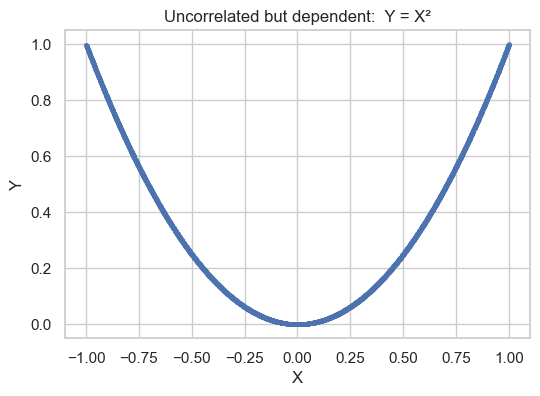

In [40]:
# The classic counterexample: Y = X^2 with X symmetric about 0.
np.random.seed(201)
X = np.random.uniform(-1, 1, 10_000)
Y = X**2                                   # Y is completely determined by X (dependent!)

print(f"Cov(X, X^2) = {np.cov(X, Y)[0, 1]:+.4f}   (≈ 0  -> uncorrelated)")
print("...yet Y is a deterministic, just non-linear function of X, so they are NOT independent. The net linear trend is 0 as the the function is symmetric about X=0")

plt.figure(figsize=(6, 4))
plt.scatter(X, Y, s=6, alpha=0.3)
plt.title("Uncorrelated but dependent:  Y = X²")
plt.xlabel("X"); plt.ylabel("Y"); plt.show()



**Takeaway:** correlation captures *linear* co-movement only. Independence is the stronger
condition we actually need for many causal arguments (recall $S \perp U$ from Lab 1).